In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
plt.ion()

In [3]:
plt.isinteractive()

True

# **Creating charts from aggregated data**

In [4]:
ser = pd.Series(
    (x ** 2 for x in range(7)),
    name="book_sales",
    index=(f"Day {x + 1}" for x in range(7)),
    dtype=pd.Int64Dtype()
)

ser

Day 1     0
Day 2     1
Day 3     4
Day 4     9
Day 5    16
Day 6    25
Day 7    36
Name: book_sales, dtype: Int64

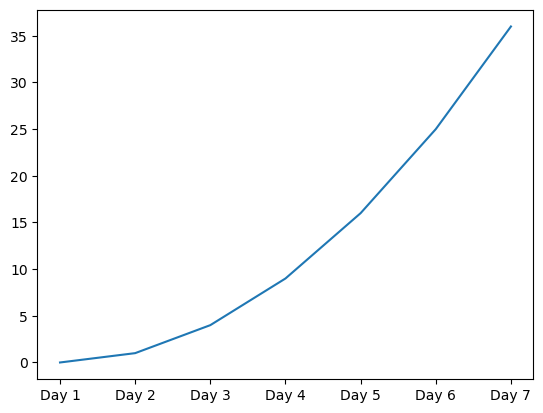

In [7]:
ser.plot() # produce a line chart by defualt

plt.show()

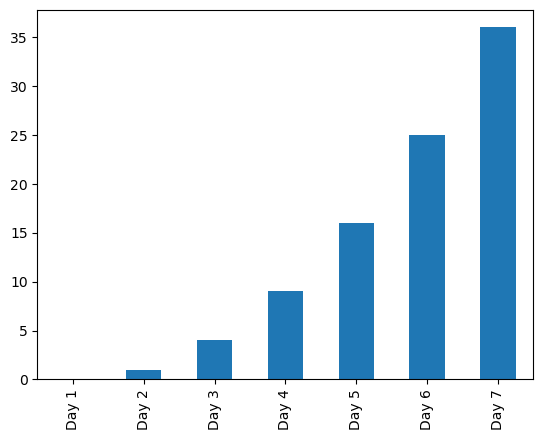

In [8]:
ser.plot(kind="bar")

plt.show()

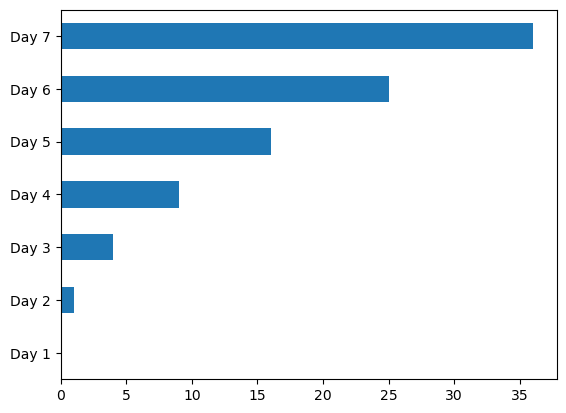

In [9]:
ser.plot(kind="barh")

plt.show()

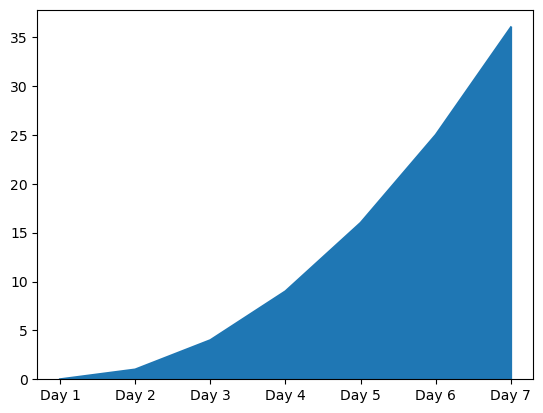

In [10]:
ser.plot(kind="area")

plt.show()

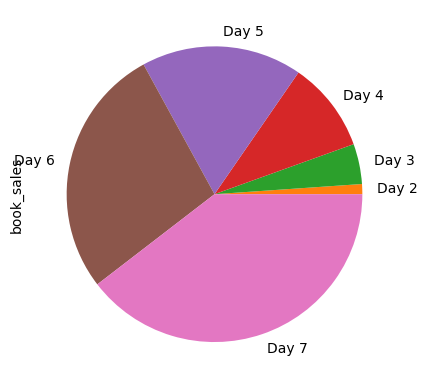

In [11]:
ser.plot(kind="pie")

plt.show()

In [12]:
df = pd.DataFrame({
    "book_sales": (x ** 2 for x in range(7)),
    "book_returns": [3, 2, 1, 0, 1, 2, 3],
}, index=(f"Day {x + 1}" for x in range(7))).convert_dtypes(dtype_backend="numpy_nullable")

df

,book_sales,book_returns
Day 1,0,3
Day 2,1,2
Day 3,4,1
Day 4,9,0
Day 5,16,1
Day 6,25,2
Day 7,36,3


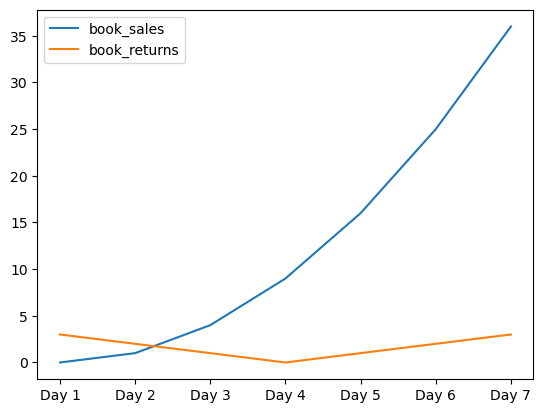

In [14]:
df.plot()

plt.show()

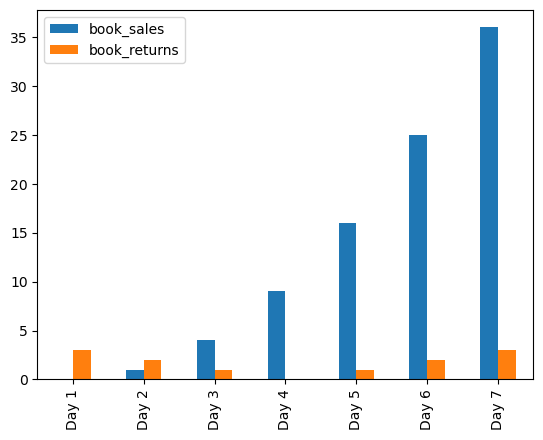

In [15]:
df.plot(kind="bar")

plt.show()

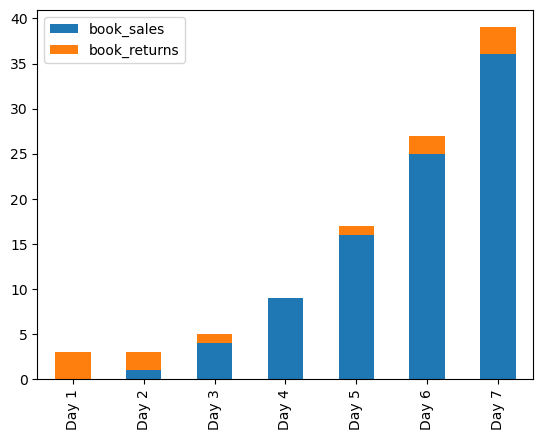

In [16]:
df.plot(kind="bar", stacked=True)

plt.show()

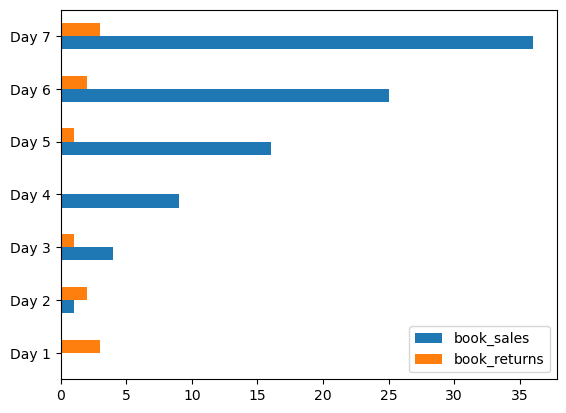

In [18]:
df.plot(kind='barh')

plt.show()

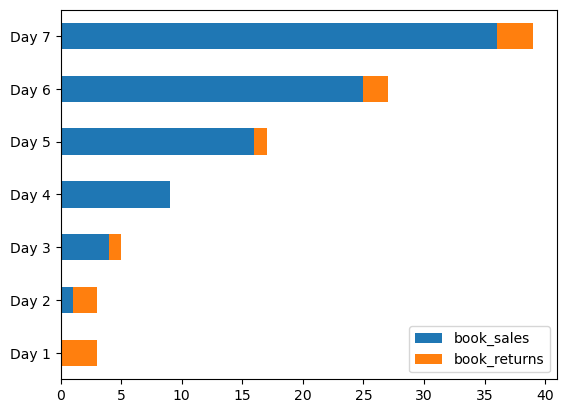

In [20]:
df.plot(kind="barh", stacked=True)

plt.show()

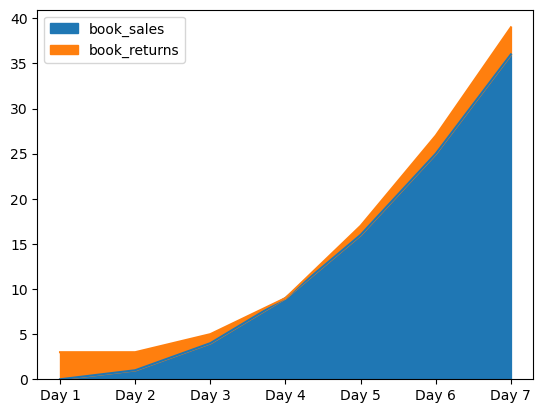

In [21]:
df.plot(kind="area")

plt.show()

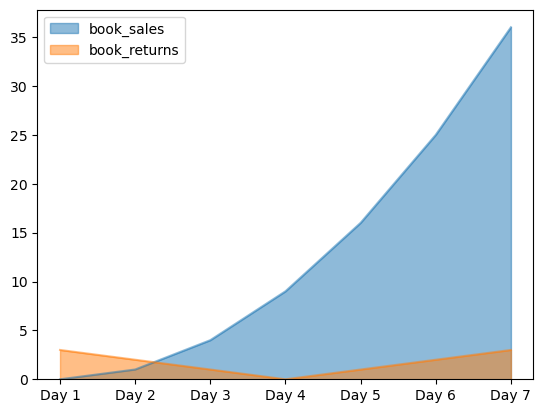

In [23]:
df.plot(kind="area", stacked=False, alpha=0.5)

plt.show()

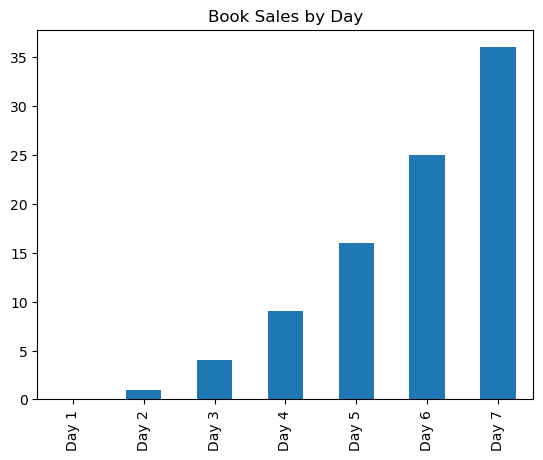

In [25]:
ser.plot(
    kind="bar",
    title="Book Sales by Day",
)

plt.show()

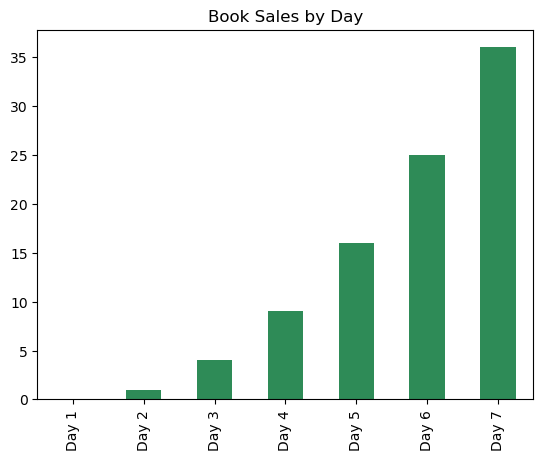

In [27]:
ser.plot(
    kind="bar",
    title="Book Sales by Day",
    color="seagreen",
)

plt.show()

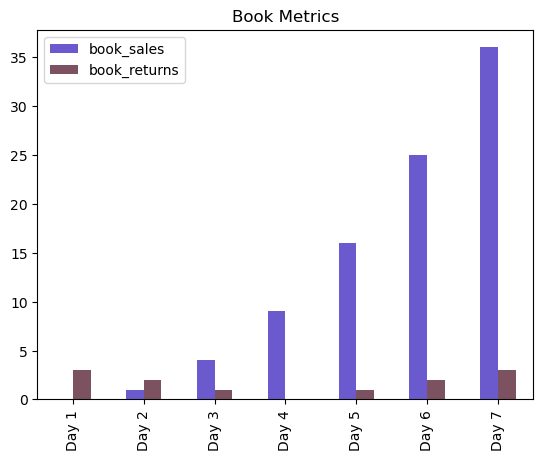

In [29]:
df.plot(
    kind="bar",
    title="Book Metrics",
    color={
        "book_sales": "slateblue",
        "book_returns": "#7D5260",
    }
)

plt.show()

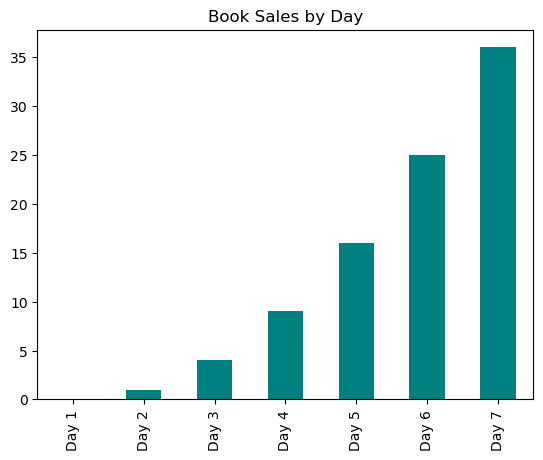

In [30]:
ser.plot(
    kind="bar",
    title="Book Sales by Day",
    color="teal",
    grid=False,
)

plt.show()

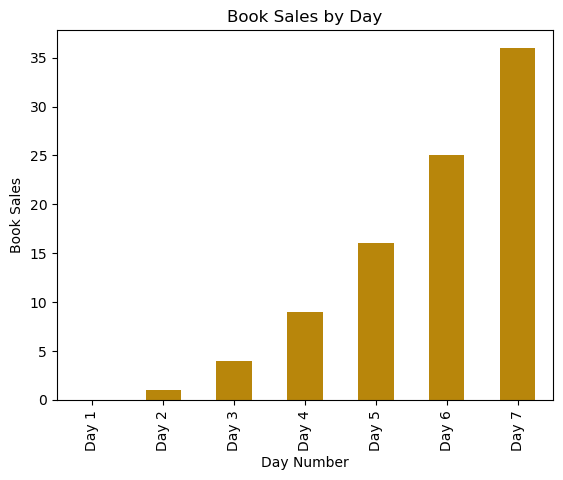

In [34]:
ser.plot(
    kind="bar",
    title="Book Sales by Day",
    color="darkgoldenrod",
    grid=False,
    xlabel="Day Number",
    ylabel="Book Sales",
)

plt.show()

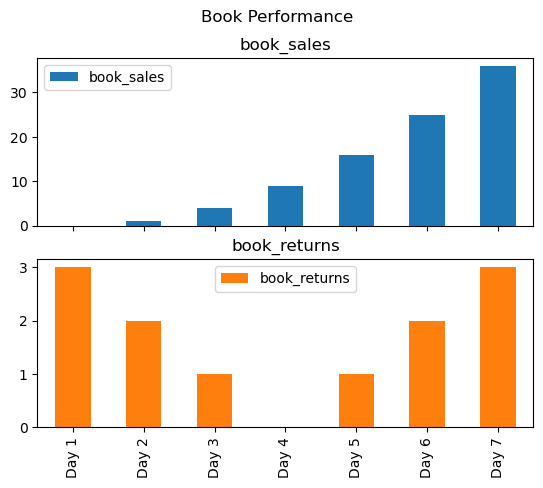

In [35]:
df.plot(
    kind="bar",
    title="Book Performance",
    grid=False,
    subplots=True,
)

plt.show()

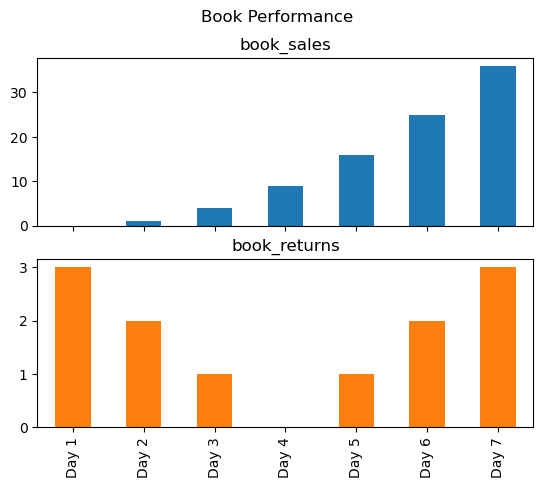

In [36]:
df.plot(
    kind="bar",
    title="Book Performance",
    grid=False,
    subplots=True,
    legend=False,
)

plt.show()

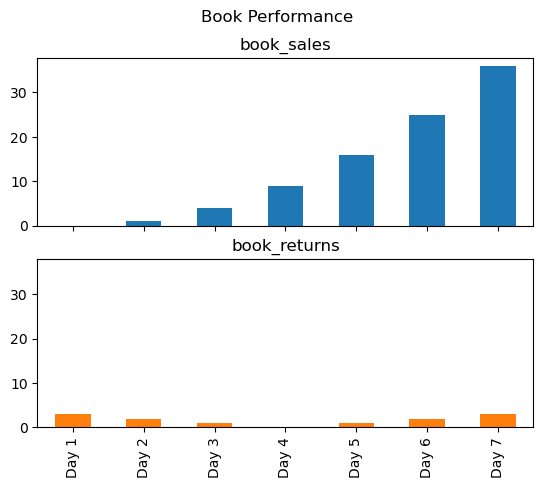

In [37]:
df.plot(
    kind="bar",
    title="Book Performance",
    grid=False,
    subplots=True,
    legend=False,
    sharey=True, # shared the y-axis accros the subplot
)

plt.show()

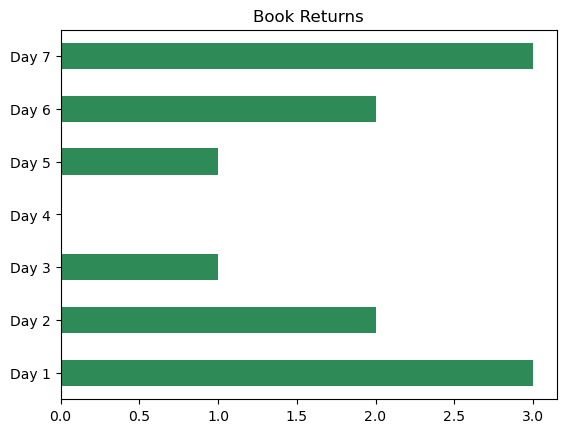

In [38]:
df.plot(
    kind="barh",
    y=["book_returns"],
    title="Book Returns",
    legend=False,
    grid=False,
    color="seagreen",
)

plt.show()

# **Plotting distributions of non-aggregated data**

In [54]:
np.random.seed(42)

ser = pd.Series(
    np.random.default_rng().normal(size=10_000),
    dtype=pd.Float64Dtype(),
)

ser

0       0.432153
1       0.779711
2      -1.033723
3         0.1702
4      -1.714065
          ...   
9995    0.025173
9996     0.53643
9997   -1.129439
9998     1.60169
9999    1.370041
Length: 10000, dtype: Float64

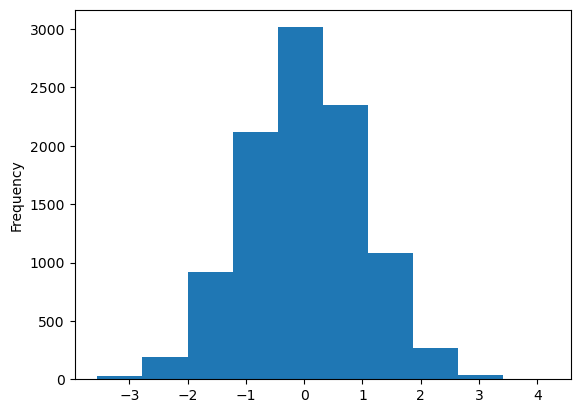

In [55]:
ser.plot(kind='hist')

plt.show()

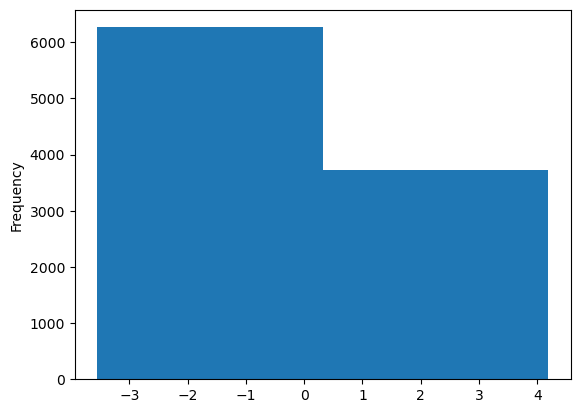

In [56]:
ser.plot(kind="hist", bins=2)

plt.show()

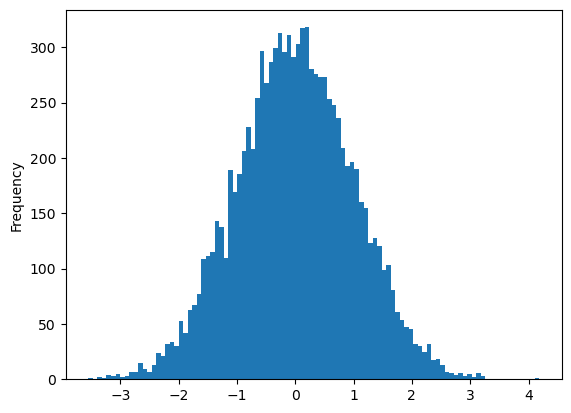

In [57]:
ser.plot(kind="hist", bins=100)

plt.show()

In [61]:
np.random.seed(42)

df = pd.DataFrame({
        "normal": np.random.default_rng().normal(size=10_000),
        "triangular": np.random.default_rng().triangular(-2, 0, 2, 10_000)
}).convert_dtypes(dtype_backend="numpy_nullable")

df.head()

,normal,triangular
0,-0.1285,0.37324
1,-0.977383,-0.388932
2,0.066651,0.496231
3,-1.119222,0.630647
4,-2.421193,1.348837


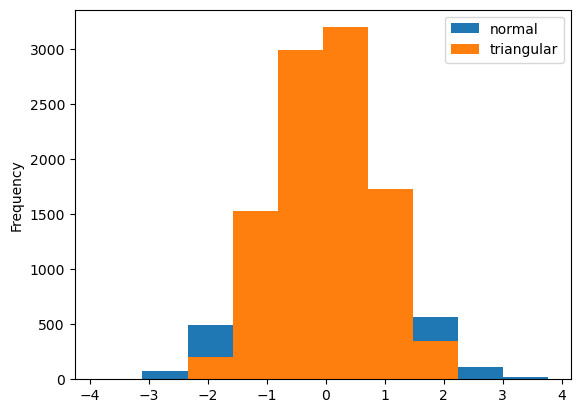

In [63]:
df.plot(kind="hist")

plt.show()

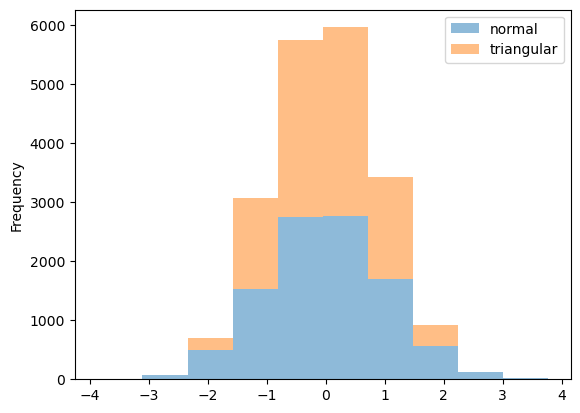

In [70]:
df.plot(kind="hist", stacked=True, alpha=0.5)

plt.show()

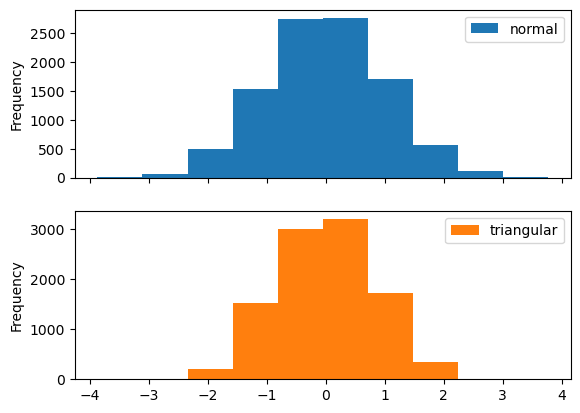

In [73]:
df.plot(kind="hist", subplots=True)

plt.show()

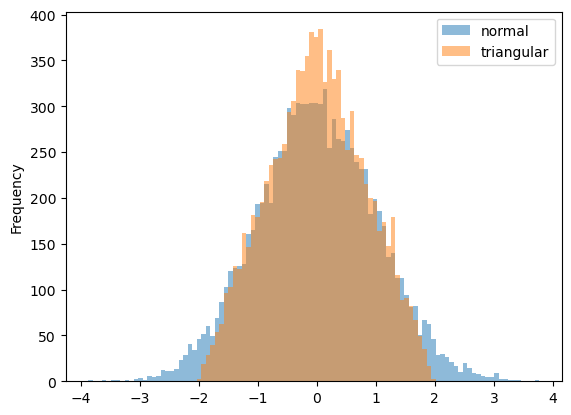

In [74]:
df.plot(kind="hist", alpha=0.5, bins=100)

plt.show()

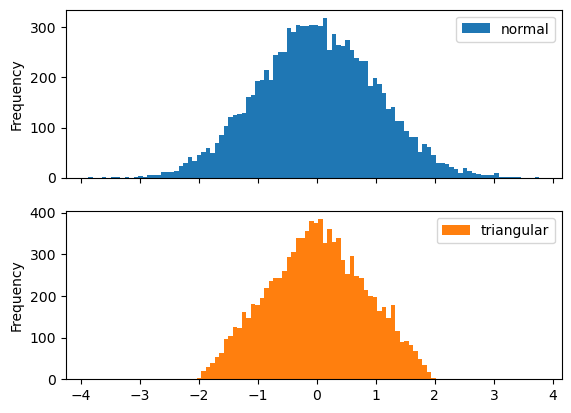

In [76]:
df.plot(kind="hist", subplots=True, bins=100)

plt.show()

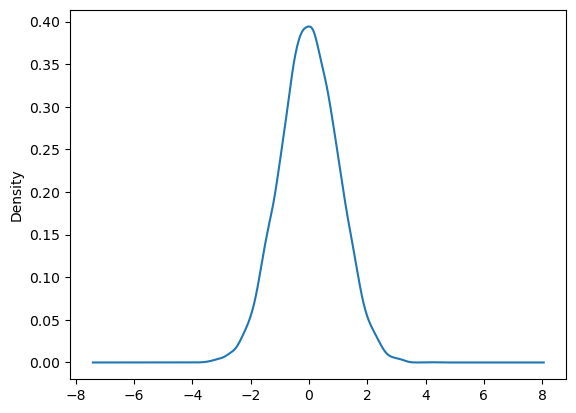

In [77]:
ser.plot(kind="kde")

plt.show()

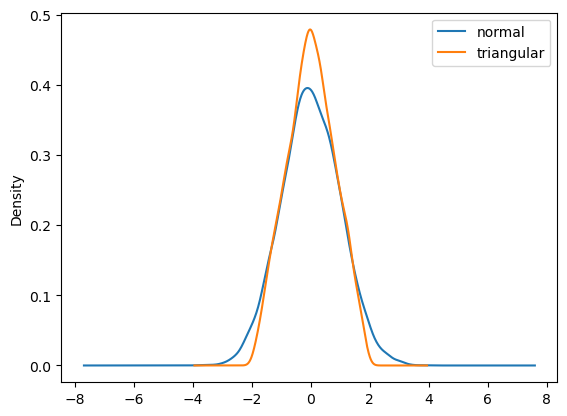

In [78]:
df.plot(kind='kde')

plt.show()

# **Further plot customization with Matplotlib**

> In **Matplotlib**, the figure refers to the drawing area, and an **axes** or **subplot** is the region on that figure that you can draw upon. Be careful not to confuse an **axes**, which is an **area** for plotting data, with an **axis**, which refers to the **X- or Y-axis**.

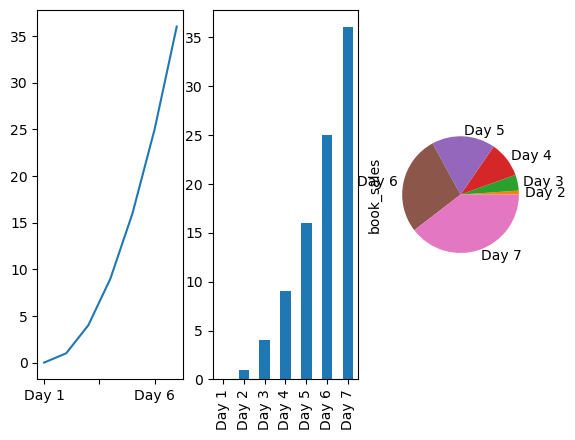

In [4]:
ser = pd.Series(
    (x ** 2 for x in range(7)),
    name="book_sales",
    index=(f"Day {x + 1}" for x in range(7)),
    dtype=pd.Int64Dtype(),
)

fig, axes = plt.subplots(nrows=1, ncols=3)
ser.plot(ax=axes[0])
ser.plot(kind="bar", ax=axes[1])
ser.plot(kind="pie", ax=axes[2])

plt.show()

In [7]:
from matplotlib.gridspec import GridSpec

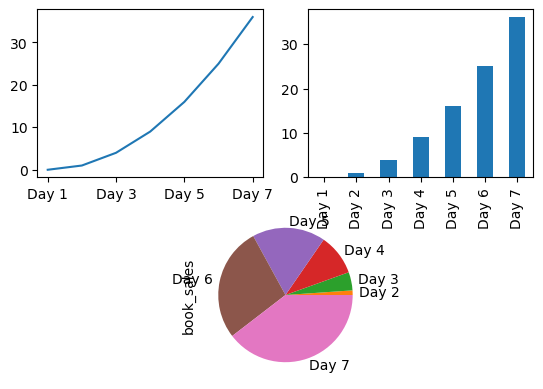

In [13]:
fig = plt.figure()
gs = GridSpec(2, 2, figure=fig)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])

ser.plot(ax=ax0)
ser.plot(kind="bar", ax=ax1)
ser.plot(kind="pie", ax=ax2)

plt.show()

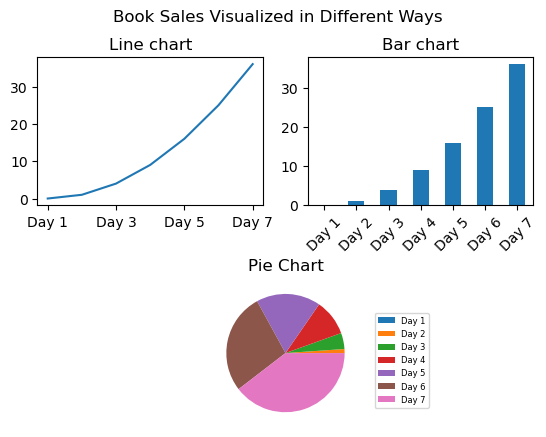

In [15]:
fig = plt.figure()
fig.suptitle("Book Sales Visualized in Different Ways")

gs = GridSpec(2, 2, figure=fig, hspace=.5)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])

ax0 = ser.plot(ax=ax0)
ax0.set_title("Line chart")

ax1 = ser.plot(kind="bar", ax=ax1)
ax1.set_title("Bar chart")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Remove labels from chart and show in custom legend instead
ax2 = ser.plot(kind="pie", ax=ax2, labels=None)
ax2.legend(
    ser.index,
    bbox_to_anchor=(1, -0.2, 0.5, 1), # put legend to right o
    prop={"size": 6}, # set font size for legend
)
ax2.set_title("Pie Chart")
ax2.set_ylabel(None) # remove book_sales label

plt.show()

# **Exploring scatter plots**

In [16]:
df = pd.DataFrame({
    "var_a": [1, 2, 3, 4, 5],
    "var_b": [1, 2, 4, 8, 16],
    "var_c": [500, 200, 600, 100, 400],
    "var_d": ["blue", "orange", "gray", "blue", "gray"],
}).convert_dtypes(dtype_backend="numpy_nullable")

df

,var_a,var_b,var_c,var_d
0,1,1,500,blue
1,2,2,200,orange
2,3,4,600,gray
3,4,8,100,blue
4,5,16,400,gray


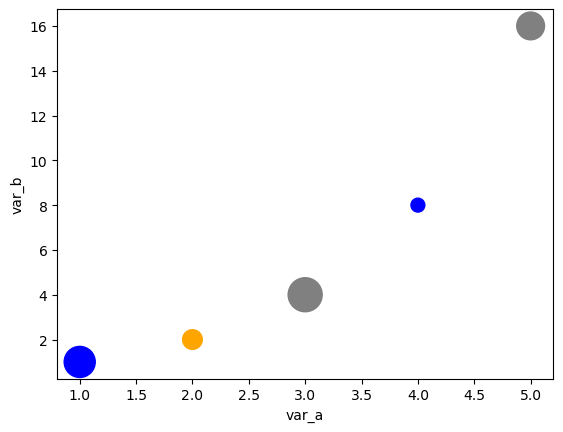

In [17]:
df.plot(
    kind="scatter",
    x="var_a",
    y="var_b",
    s="var_c",
    c="var_d",
)

plt.show()

In [18]:
df = pd.read_csv(
    "../Datasets/vehicles.csv.zip",
    dtype_backend="numpy_nullable",
    usecols=["city08", "highway08", "VClass", "fuelCost08", "year"]
)

df.head()

,city08,fuelCost08,highway08,VClass,year
0,19,2450,25,Two Seaters,1985
1,9,4700,14,Two Seaters,1985
2,23,1900,33,Subcompact Cars,1985
3,10,4700,12,Vans,1985
4,17,3400,23,Compact Cars,1993


In [19]:
car_classes = (
    "Subcompact Cars",
    "Compact Cars",
    "Midsize Cars",
    "Large Cars",
    "Two Seaters",
)

mask = (df["year"] >= 2015) & (df["VClass"].isin(car_classes))
df = df[mask]

df.head()

,city08,fuelCost08,highway08,VClass,year
27058,16,3400,23,Subcompact Cars,2015
27059,20,2250,28,Compact Cars,2015
27060,26,1700,37,Midsize Cars,2015
27061,28,1600,39,Midsize Cars,2015
27062,25,1800,35,Midsize Cars,2015


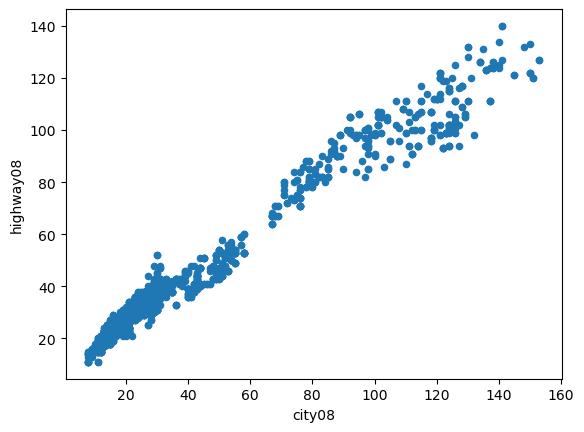

In [20]:
df.plot(
    kind="scatter",
    x="city08",
    y="highway08",
)

plt.show()

In [21]:
classes_ser = pd.Series(car_classes, dtype=pd.StringDtype())
cat = pd.CategoricalDtype(classes_ser)
df["VClass"] = df["VClass"].astype(cat)

df.head()

,city08,fuelCost08,highway08,VClass,year
27058,16,3400,23,Subcompact Cars,2015
27059,20,2250,28,Compact Cars,2015
27060,26,1700,37,Midsize Cars,2015
27061,28,1600,39,Midsize Cars,2015
27062,25,1800,35,Midsize Cars,2015


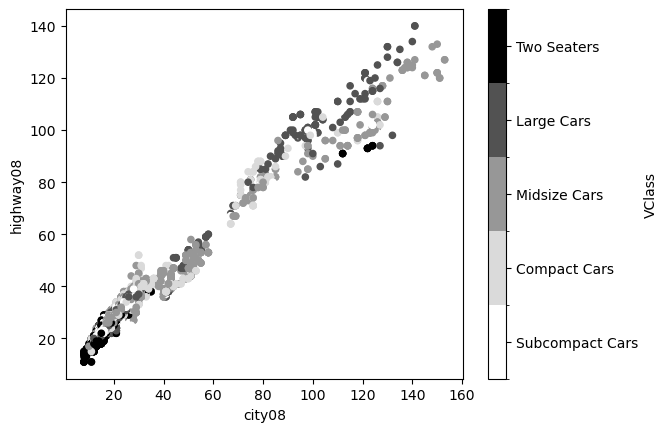

In [22]:
df.plot(
    kind="scatter",
    x="city08",
    y="highway08",
    c="VClass",
)

plt.show()

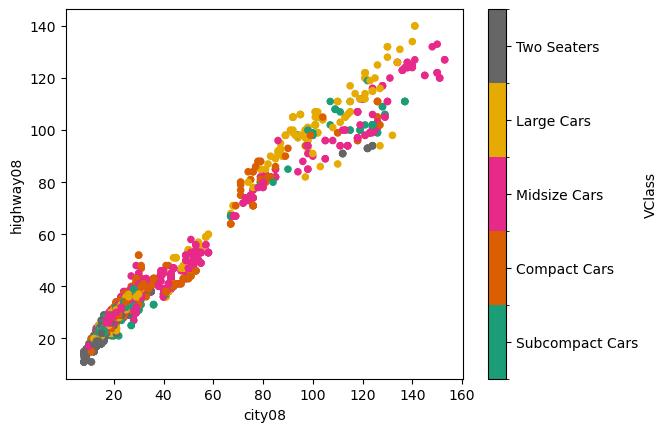

In [23]:
df.plot(
    kind="scatter",
    x="city08",
    y="highway08",
    c="VClass",
    colormap="Dark2",
)

plt.show()

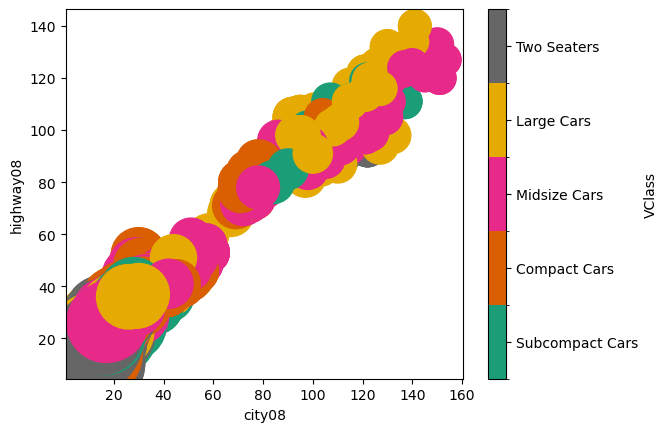

In [24]:
df.plot(
    kind="scatter",
    x="city08",
    y="highway08",
    c="VClass",
    colormap="Dark2",
    s="fuelCost08",
)

plt.show()

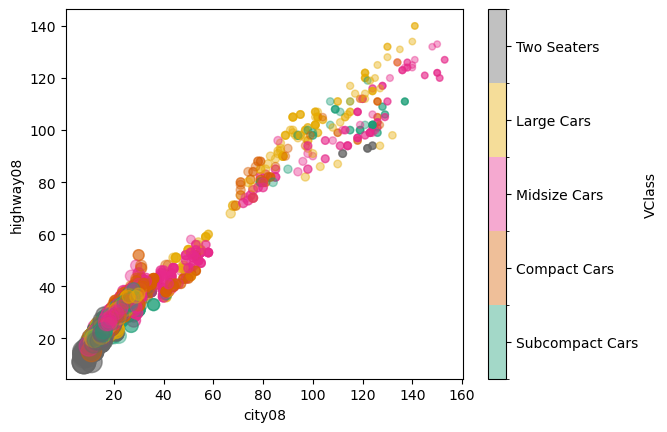

In [25]:
df.assign(
    scaled_fuel_cost=lambda x: x["fuelCost08"] / 25,
).plot(
    kind="scatter",
    x="city08",
    y="highway08",
    c="VClass",
    colormap="Dark2",
    s="scaled_fuel_cost",
    alpha=0.4,
)

plt.show()

In [26]:
from pandas.plotting import scatter_matrix

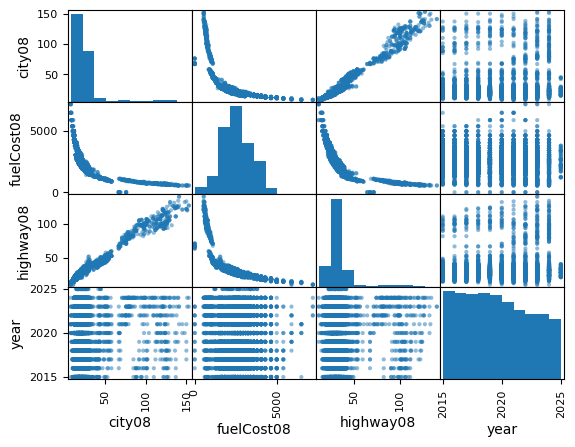

In [28]:
scatter_matrix(df)

plt.show()

# **Exploring categorical data**

In [29]:
df = pd.read_csv(
    "../Datasets/vehicles.csv.zip",
    dtype_backend="numpy_nullable",
)

df.head()

/tmp/ipykernel_4834/2160829554.py:1: DtypeWarning: Columns (72,74,75,77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
0,14.167143,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0
1,27.046364,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0
2,11.018889,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0
3,27.046364,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0
4,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0


In [30]:
df.iloc[:, [72, 74, 75, 77]]

,rangeA,mfrCode,c240Dscr,c240bDscr
0,<NA>,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>
3,<NA>,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...
47518,<NA>,<NA>,<NA>,<NA>
47519,<NA>,<NA>,<NA>,<NA>
47520,<NA>,<NA>,<NA>,<NA>
47521,<NA>,<NA>,<NA>,<NA>


In [37]:
df.dtypes.iloc[72:78]

rangeA                object
evMotor       string[python]
mfrCode               object
c240Dscr              object
charge240b           Float64
c240bDscr             object
dtype: object

In [40]:
df["rangeA"].value_counts()

rangeA
290    74
270    58
280    56
310    41
277    38
       ..
45      1
36      1
42      1
327     1
166     1
Name: count, Length: 264, dtype: int64

In [42]:
df["rangeA"].str.isnumeric().idxmax()

7116

In [48]:
df.iloc[:, [74, 75, 77]].pipe(pd.isna).idxmin()

mfrCode      23147
c240Dscr     25661
c240bDscr    25661
dtype: int64

In [49]:
df = pd.read_csv(
    "../Datasets/vehicles.csv.zip",
    dtype_backend="numpy_nullable",
    dtype={
        "rangeA": pd.StringDtype(),
        "mfrCode": pd.StringDtype(),
        "c240Dscr": pd.StringDtype(),
        "c240bDscr": pd.StringDtype()
    }
)

df.head()

,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,...,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
0,14.167143,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0
1,27.046364,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0
2,11.018889,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0
3,27.046364,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0
4,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,...,<NA>,<NA>,0.0,<NA>,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,<NA>,0,0,0


In [51]:
df.select_dtypes(include=["string"]).columns

Index(['drive', 'eng_dscr', 'fuelType', 'fuelType1', 'make', 'model',
       'mpgData', 'trany', 'VClass', 'baseModel', 'guzzler', 'trans_dscr',
       'tCharger', 'sCharger', 'atvType', 'fuelType2', 'rangeA', 'evMotor',
       'mfrCode', 'c240Dscr', 'c240bDscr', 'createdOn', 'modifiedOn',
       'startStop'],
      dtype='object')

In [54]:
df.select_dtypes(include=["string"]).nunique().sort_values()

tCharger         1
sCharger         1
mpgData          2
startStop        2
guzzler          3
fuelType2        4
c240Dscr         5
drive            7
fuelType1        7
c240bDscr        7
atvType          9
fuelType        15
VClass          34
trany           40
trans_dscr      52
mfrCode         56
make           144
rangeA         245
modifiedOn     298
evMotor        400
createdOn      455
eng_dscr       608
baseModel     1451
model         5064
dtype: int64

KeyError: 1

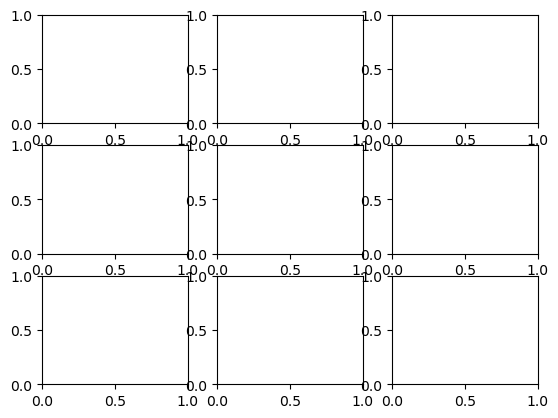

In [59]:
low_card = df.select_dtypes(include=["string"]).nunique().sort_values()

fig, axes = plt.subplots(nrows=3, ncols=3)

for index, column in enumerate(low_card):
    row = index % 3
    col = index // 3
    ax = axes[row][col]
    df[column].value_counts().plot(kind="bar", ax=ax)
plt.tight_layout()

plt.show()

KeyError: 1

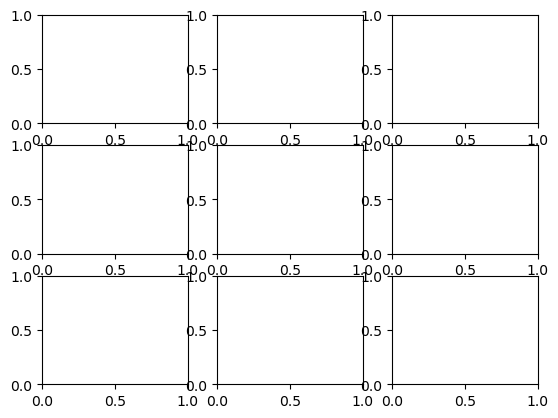

In [62]:
low_card = df.select_dtypes(include=["string"]).nunique().sort_values()
fig, axes = plt.subplots(nrows=3, ncols=3)

for index, column in enumerate(low_card):
    row = index % 3
    col = index // 3
    ax = axes[row][col]
    counts = df[column].value_counts()
    counts.set_axis(counts.index.str[:8]).plot(kind="bar", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()

plt.show()

# **Exploring continuous data**